In [1]:
!pip install roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 285.0/285.0 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 46.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 110.8 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92


In [2]:
from kaggle_secrets import UserSecretsClient
from roboflow import Roboflow

user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("ROBOFLOW_API_KEY")


rf = Roboflow(api_key = secret_value_0)
project = rf.workspace("aegis").project("pothole-detection-i00zy")
version = project.version(8)
dataset = version.download("yolo26")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Pothole-Detection--8 in yolo26:: 100%|██████████| 7116/7116 [00:00<00:00, 10681.65it/s]


In [3]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 21.4 MB/s eta 0:00:00


In [4]:
from ultralytics import YOLO

model = YOLO('yolo26s.pt')

results = model.train(
    data = f'{dataset.location}/data.yaml', 
    epochs = 100,
    patience = 25,
    imgsz = 640,
    batch=32,
    device = [0,1],
    project='kaggle_yolo',
    name='pothole_detector'
)

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.117 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
                                                        CUDA:1 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/Pothole-Detection--8/data.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dy

Testing on image: 205_png.rf.50ceff342a9269fb90d07b1895067120.jpg

image 1/1 /kaggle/working/Pothole-Detection--8/test/images/205_png.rf.50ceff342a9269fb90d07b1895067120.jpg: 352x640 2 potholes, 11.5ms
Speed: 12.2ms preprocess, 11.5ms inference, 0.8ms postprocess per image at shape (1, 3, 352, 640)


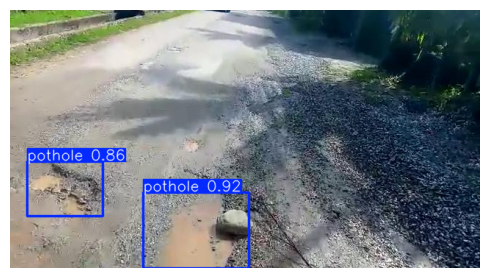

In [5]:
import os
import random
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2

model_path = '/kaggle/working/runs/detect/kaggle_yolo/pothole_detector/weights/best.pt'
trained_model = YOLO(model_path)

test_dir = f"{dataset.location}/test/images/"
all_test_images = os.listdir(test_dir)
random_image_name = random.choice(all_test_images)
test_image_path = os.path.join(test_dir, random_image_name)

print(f"Testing on image: {random_image_name}")

results = trained_model.predict(source=test_image_path, conf=0.5)

result = results[0]
plotted_image = result.plot() 
plotted_image_rgb = cv2.cvtColor(plotted_image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5, 5))
plt.imshow(plotted_image_rgb)
plt.axis('off')
plt.tight_layout()
plt.show()